In [6]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [7]:
import requests
import json

def get_weather(loc):
    """
    Function to query content weather.
    "param loc: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the loc parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    """

    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")

    # step 2 设置查询参数
    params={
        "q":loc,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }

    response=requests.get(url,params=params)

    data=response.json()
    return json.dumps(data)

In [8]:
get_weather("beijing")

'{"coord": {"lon": 116.3972, "lat": 39.9075}, "weather": [{"id": 804, "main": "Clouds", "description": "\\u9634\\uff0c\\u591a\\u4e91", "icon": "04n"}], "base": "stations", "main": {"temp": 23.68, "feels_like": 24.09, "temp_min": 23.68, "temp_max": 23.68, "pressure": 1002, "humidity": 76, "sea_level": 1002, "grnd_level": 998}, "visibility": 10000, "wind": {"speed": 3.07, "deg": 124, "gust": 4.46}, "clouds": {"all": 100}, "dt": 1781885373, "sys": {"country": "CN", "sunrise": 1781901946, "sunset": 1781955957}, "timezone": 28800, "id": 1816670, "name": "Beijing", "cod": 200}'

In [9]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData, Float
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别

# 创建基类
Base = declarative_base()

class Weather(Base):
    __tablename__ = 'weather'
    city_id = Column(Integer, primary_key=True)
    city_name = Column(String(50))
    main_weather = Column(String(50))
    description = Column(String(100))
    temperature = Column(Float)
    feels_like=Column(Float)
    temp_min=Column(Float)
    temp_max=Column(Float)

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-06-20 00:10:31,088 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-06-20 00:10:31,089 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-20 00:10:31,094 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-06-20 00:10:31,095 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-20 00:10:31,096 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-06-20 00:10:31,097 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-20 00:10:31,099 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-20 00:10:31,100 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`weather`
2026-06-20 00:10:31,101 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-20 00:10:31,113 INFO sqlalchemy.engine.Engine COMMIT


In [10]:
from typing import Optional
from langchain_core.tools import tool
import requests ,json

class WeatherLoc(BaseModel):
    location:str=Field(description="the location to get the weather")

class WeatherInfo(BaseModel):
    """Extracted weather information for a city"""
    city_id:str=Field(...,description="The unique identifier for the city")
    city_name:Optional[str]=Field(description="name of the city")
    main_weather:str=Field(description="main weather condition")
    description:Optional[str]=Field(description="a detailed description of the weather")
    temperature:Optional[str]=Field(description="current temperature of the city")
    feels_like:Optional[str]=Field(description="feels-like temperature of the city")
    temp_min:Optional[str]=Field(description="minimum temperature of the city")
    temp_max:Optional[str]=Field(description="maximum temperature of the city")

@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    
    从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。
    优先使用 query_weather_from_db 工具。
    
    Function to query content weather.
    "param location: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the location parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    
    """
    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")
    # step 2 设置查询参数
    params={
        "q":location,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }
    response=requests.get(url,params=params)
    data=response.json()
    return json.dumps(data)

@tool(args_schema=WeatherInfo)
def insert_weather_to_db(city_id,city_name,main_weather,description,temperature,feels_like,temp_min,temp_max):
    """insert weather information into the database"""
    session=Session()
    try:
        weather=Weather(city_id=city_id,city_name=city_name,main_weather=main_weather,
                        description=description,temperature=temperature,feels_like=feels_like,temp_min=temp_min,temp_max=temp_max)
        session.merge(weather)
        session.commit()
        return {"messages":[f"天气数据已成功存储到db"]}
    except Exception as e:
        session.rollback()
        return {"messages":[f"天气数据保存失败，错误是{e}"]}
    finally:
        session.close()
        
class QueryWeatherSchema(BaseModel):
    """Schema for querying weather information by city name"""
    city_name: str=Field(..., description="The name of the city to query weather information")

@tool(args_schema=QueryWeatherSchema)
def query_weather_from_db(city_name):
    """query weather information from db by city name"""
    session=Session()
    try:
        weather_data=session.query(Weather).filter(Weather.city_name==city_name).first()
        if weather_data:
            return {
                "city_id":weather_data.city_id,
                "city_name":weather_data.city_name,
                "main_weather":weather_data.main_weather,
                "description":weather_data.description,
                "temperature":weather_data.temperature,
                "feels_like":weather_data.feels_like,
                "temp_min":weather_data.temp_min,
                "temp_max":weather_data.temp_max
            }
        else:
            return {"messages":[f"未找到城市 {city_name} 的天气信息"]}
    except Exception as e:
        return {"messages":[f"查询失败，错误原因, {e}"]}
    finally:
        session.close()

In [11]:
result=query_weather_from_db.invoke({"city_name":"beijing"})
result

2026-06-20 00:10:31,304 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-20 00:10:31,308 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-06-20 00:10:31,309 INFO sqlalchemy.engine.Engine [generated in 0.00116s] {'city_name_1': 'beijing', 'param_1': 1}
2026-06-20 00:10:31,311 INFO sqlalchemy.engine.Engine ROLLBACK


{'city_id': 1816670,
 'city_name': 'Beijing',
 'main_weather': 'Clouds',
 'description': '阴，多云',
 'temperature': 23.68,
 'feels_like': 24.09,
 'temp_min': 23.68,
 'temp_max': 23.68}

In [12]:
class SearchQuery(BaseModel):
    """the query to fetch real time infor"""
    query: str = Field(description="the query to fetch real time infor")


@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """fetch real time info from internet"""
    print("--------------")
    url = os.getenv("BAIDU_API_URL")

    payload = json.dumps(
        {
            "messages": [{"role": "user", "content": query}],
            "edition": "standard",
            "search_source": "baidu_search_v2",
            "search_recency_filter": "week",
        },
        ensure_ascii=False,
    )
    headers = {
        "Content-Type": "application/json",
        "Authorization": "Bearer " + os.getenv("BAIDU_API_KEY"),
    }

    response = requests.request(
        "POST", url, headers=headers, data=payload.encode("utf-8")
    )

    response.encoding = "utf-8"
    print(response.text)

    response = requests.get(url)
    result = json.loads(response.text)
    return result

In [13]:
tools=[fetch_real_time_info,get_weather,insert_weather_to_db,query_weather_from_db]
tools

[StructuredTool(name='fetch_real_time_info', description='fetch real time info from internet', args_schema=<class '__main__.SearchQuery'>, func=<function fetch_real_time_info at 0x000001F3256A0220>),
 StructuredTool(name='get_weather', description='从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。\n优先使用 query_weather_from_db 工具。\n\nFunction to query content weather.\n"param location: Required parameter, of type string, representing the specific city name for the weather query.\nNote that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,\nthe location parameter should be input as \'Beijing\'.\n:return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.\nThe return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.', args_schema=<class '__main__.WeatherLoc'

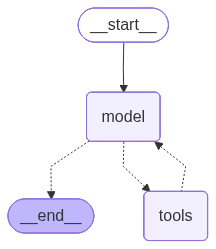

In [14]:
from langchain.agents import create_agent

graph=create_agent(llm,tools)
graph


In [15]:
async for event in graph.astream_events({"messages":["你好，请你介绍一下你自己"]},version="v2"):
    kind=event["event"]
    print(f"{kind}:{event['name']}")

on_chain_start:LangGraph
on_chain_start:model
on_chat_model_start:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOp

In [16]:
events=[]
async for event in graph.astream_events({"messages":["你好，请你介绍一下你自己"]},version="v2"):
    events.append(event)

events[0]    

{'event': 'on_chain_start',
 'data': {'input': {'messages': ['你好，请你介绍一下你自己']}},
 'name': 'LangGraph',
 'tags': [],
 'run_id': '019ee0a7-68ef-74a0-8fa4-3d6e39aebfa5',
 'metadata': {'ls_integration': 'langchain_create_agent',
  'LANGSMITH_ENDPOINT': 'https://api.smith.langchain.com',
  'LANGSMITH_PROJECT': 'chat',
  'LANGSMITH_TRACING': 'true',
  'revision_id': 'ad2016b'},
 'parent_ids': []}

In [ ]:
async for event in graph.astream_events({"messages":["你好，请你介绍一下你自己"]},version='v2'):
    kind=event['event']
    if kind =='on_chat_model_stream':
        print(event,end="|",flush=True)

In [21]:
async for event in graph.astream_events({"messages":["你好，查询一下天津滨海新区的天气"]},version="v2"):
    kind=event["event"]
    if kind=="on_chat_model_stream":
        print(event["data"]['chunk'].content,end="",flush=True)

我来查询天津滨海新区的天气信息。首先，让我查一下数据库中有没有相关数据。2026-06-20 00:16:42,080 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-20 00:16:42,087 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-06-20 00:16:42,088 INFO sqlalchemy.engine.Engine [cached since 370.8s ago] {'city_name_1': 'Tianjin', 'param_1': 1}
2026-06-20 00:16:42,091 INFO sqlalchemy.engine.Engine ROLLBACK
数据库中没有天津的天气信息，让我通过实时天气API来查询。让我把查询到的天气信息存入数据库。2026-06-20 00:16:47,071 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-20 00:16:47,074 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_c